# Marketplace Safety – Machine Learning

## Gruppuppgift / individuell inlämning

I det här projektet bygger jag en lösning för att hjälpa ett Trust & Safety team att prioritera misstänkta händelser i en marketplace-app.

Varje rad i datasetet representerar en händelse på plattformen, till exempel en annons eller ett meddelande. Målet är att klassificera om händelsen är misstänkt eller inte.

Target-variabeln är:

- `is_suspicious = 1`: misstänkt händelse
- `is_suspicious = 0`: ej misstänkt händelse

Eftersom uppgiften handlar om prioritering är målet inte att få 100% rätt, utan att bygga en modell som fungerar rimligt bra, går att förklara och kan användas som beslutsstöd.

In [1]:
# Grundläggande bibliotek
from pathlib import Path

import numpy as np
import pandas as pd

# Visualisering
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

# Inställningar
RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Sökvägar
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "historical_data.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/Users/SG199/Desktop/VS CODE REPOS/marketplace-safety-ml/data/raw/historical_data.csv')

In [3]:
df = pd.read_csv(DATA_PATH)

df.head()

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


In [4]:
print(f"Antal rader: {df.shape[0]}")
print(f"Antal kolumner: {df.shape[1]}")

df.info()

Antal rader: 12000
Antal kolumner: 18
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  str    
 3   category                    12000 non-null  str    
 4   region                      11660 non-null  str    
 5   device                      12000 non-null  str    
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  cont

## 1. Dataförståelse

Datasetet innehåller 12 000 historiska händelser från en marketplace-plattform. Varje rad motsvarar en händelse, till exempel en annons eller ett meddelande.

Datan innehåller både numeriska signaler, som pris, kontots ålder och antal tidigare rapporter, samt kategoriska signaler, som region, device, kategori och event-typ.

Target-kolumnen heter `is_suspicious` och visar om händelsen tidigare har bedömts som misstänkt eller inte.

In [5]:
target_counts = df["is_suspicious"].value_counts().sort_index()
target_percent = df["is_suspicious"].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "Antal": target_counts,
    "Andel (%)": target_percent.round(2)
})

target_distribution

,Antal,Andel (%)
is_suspicious,,
0,10776,89.8
1,1224,10.2


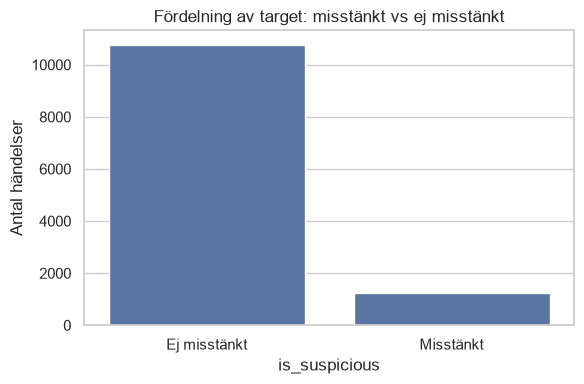

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="is_suspicious"
)

plt.title("Fördelning av target: misstänkt vs ej misstänkt")
plt.xlabel("is_suspicious")
plt.ylabel("Antal händelser")
plt.xticks([0, 1], ["Ej misstänkt", "Misstänkt"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150)
plt.show()

### Target-fördelning

Target-fördelningen visar att majoriteten av händelserna inte är misstänkta. Ungefär 10% av raderna är markerade som misstänkta.

Det betyder att datan är obalanserad. Därför räcker det inte att bara titta på accuracy. En modell kan få hög accuracy genom att nästan alltid gissa "ej misstänkt", men det skulle inte hjälpa Trust & Safety-teamet så mycket.

Vii nehöver därför även titta på mått som precision, recall, F1 och PR-AUC.

In [7]:
missing_values = pd.DataFrame({
    "Antal saknade": df.isna().sum(),
    "Andel saknade (%)": (df.isna().mean() * 100).round(2)
})

missing_values = missing_values[missing_values["Antal saknade"] > 0]
missing_values

,Antal saknade,Andel saknade (%)
region,340,2.83
price,818,6.82
time_to_first_response_min,590,4.92


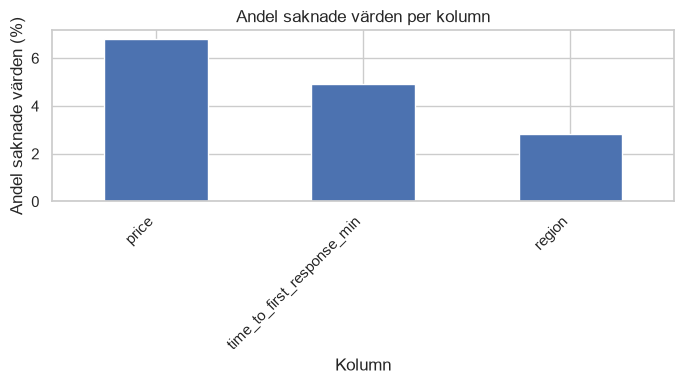

In [8]:
plt.figure(figsize=(7, 4))

missing_values["Andel saknade (%)"].sort_values(ascending=False).plot(kind="bar")

plt.title("Andel saknade värden per kolumn")
plt.xlabel("Kolumn")
plt.ylabel("Andel saknade värden (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_values.png", dpi=150)
plt.show()

### Saknade värden

Det finns saknade värden i `region`, `price` och `time_to_first_response_min`.

Det är realistiskt för den här typen av data. Alla annonser kanske inte har ett pris, alla händelser kanske inte har en tydlig region och vissa svarstider kan saknas.

Jag tar intee bort dessa rader, eftersom det skulle göra att vi tappar data. I stället hanteras saknade värden senare i en pipeline:

- numeriska kolumner fylls med medianvärde
- kategoriska kolumner fylls med ett särskilt värde, till exempel `"missing"`

Det gör också att samma hantering kan användas på både train, test och framtida `new_data.csv`.

In [9]:
event_type_summary = (
    df.groupby("event_type")["is_suspicious"]
    .agg(["count", "mean"])
    .rename(columns={
        "count": "Antal händelser",
        "mean": "Andel misstänkta"
    })
)

event_type_summary["Andel misstänkta (%)"] = (event_type_summary["Andel misstänkta"] * 100).round(2)
event_type_summary = event_type_summary.drop(columns="Andel misstänkta")

event_type_summary.sort_values("Andel misstänkta (%)", ascending=False)

,Antal händelser,Andel misstänkta (%)
event_type,,
message_send,3465,10.71
ad_post,8535,9.99


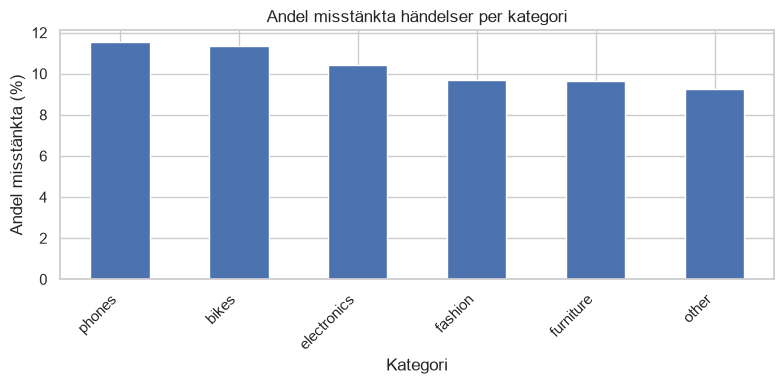

In [10]:
category_risk = (
    df.groupby("category")["is_suspicious"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8, 4))

category_risk.plot(kind="bar")

plt.title("Andel misstänkta händelser per kategori")
plt.xlabel("Kategori")
plt.ylabel("Andel misstänkta (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "suspicious_rate_by_category.png", dpi=150)
plt.show()

### Skillnader mellan grupper

EDA:n visar att risken inte är helt jämnt fördelad mellan olika typer av händelser och kategorier. Vissa grupper har högre andel misstänkta händelser än andra.

Det betyder att kategoriska variabler som `event_type`, `category`, `region` och `device` kan vara användbara signaler för modelllen.

Samtidigt måste modellen tränas på ett leakage säkert sätt, så encoding och imputation görs senare inne i en scikit learn pippeline.